In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('video_sessions_transformed.csv')
df.head()

,user_id,video_owner_id,total_view_time,vk_platform,nav_screen,video_id
0,5137060586,197846393764,0,vk_video_ios,video_for_you,1524753638856
1,6791352918,255312742952,0,vk_video_android,video_search,1524750811524
2,8499858010,290290140528,2,vk_video_android,video_for_you,1524751697154
3,13064371614,296968444192,0,vk_video_android,video_search,1524751112304
4,15865765790,283074246524,0,vk_video_android,video_for_you,1524752278662


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4503 entries, 0 to 4502
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          4503 non-null   int64 
 1   video_owner_id   4503 non-null   int64 
 2   total_view_time  4503 non-null   int64 
 3   vk_platform      4503 non-null   object
 4   nav_screen       4503 non-null   object
 5   video_id         4503 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 211.2+ KB


In [4]:
# данные о времени просмотра разного масштаба, стандатизируем их, используя метод устойчивый к выбросам
df[df['total_view_time'] > 0].total_view_time.min(), df[df['total_view_time'] > 0].total_view_time.max()

(np.int64(1), np.int64(240502233))

In [5]:
# нам нужны только осознанные промсотры
non_zero_time = df[df['total_view_time'] >= 30]
non_zero_time.head()

,user_id,video_owner_id,total_view_time,vk_platform,nav_screen,video_id
18,95099822804,140097381168,2276,vk_video_ios,video_search,1524763681566
51,296346924566,291304532396,9256,vk_video_android,video_search,1524752816724
58,325847601072,-305298731784,30,vk_video_android,video_search,571384527228
59,333008604698,-4391730508,53,vk_video_android,video_my_added,1524756920700
69,392460525982,279672446984,1184,vk_video_android,video_my_history,1524754758426


In [6]:
# стандартизируем total_view_time
scaler = RobustScaler()
scaled_time = scaler.fit_transform(non_zero_time[['total_view_time']])

In [7]:
non_zero_time['scaled_time'] = scaled_time
non_zero_time.head()

C:\Users\Данил\AppData\Local\Temp\ipykernel_62912\3700882664.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_zero_time['scaled_time'] = scaled_time


,user_id,video_owner_id,total_view_time,vk_platform,nav_screen,video_id,scaled_time
18,95099822804,140097381168,2276,vk_video_ios,video_search,1524763681566,0.667980
51,296346924566,291304532396,9256,vk_video_android,video_search,1524752816724,4.106404
58,325847601072,-305298731784,30,vk_video_android,video_search,571384527228,-0.438424
59,333008604698,-4391730508,53,vk_video_android,video_my_added,1524756920700,-0.427094
69,392460525982,279672446984,1184,vk_video_android,video_my_history,1524754758426,0.130049


{'whiskers': [<matplotlib.lines.Line2D at 0x1dee4601640>,
 'caps': [<matplotlib.lines.Line2D at 0x1dee4601b80>,
 'boxes': [<matplotlib.lines.Line2D at 0x1dee4601430>],
 'medians': [<matplotlib.lines.Line2D at 0x1dee461c100>],
 'fliers': [<matplotlib.lines.Line2D at 0x1dee461c3a0>],
 'means': []}

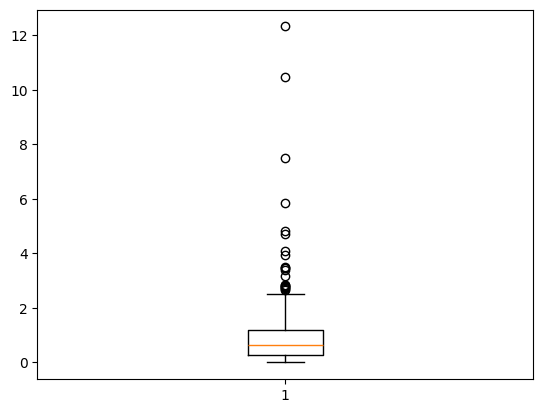

In [8]:
plt.boxplot(non_zero_time[(non_zero_time['scaled_time'] > 0) & (non_zero_time['scaled_time'] < 100)].scaled_time)

{'whiskers': [<matplotlib.lines.Line2D at 0x1dee68b03a0>,
 'caps': [<matplotlib.lines.Line2D at 0x1dee68b08e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1dee68b0100>],
 'medians': [<matplotlib.lines.Line2D at 0x1dee68b0e20>],
 'fliers': [<matplotlib.lines.Line2D at 0x1dee68bd100>],
 'means': []}

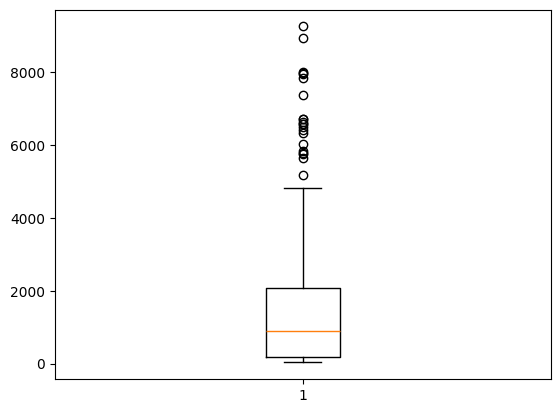

In [13]:
plt.boxplot(non_zero_time[(non_zero_time['total_view_time'] > 0) & (non_zero_time['total_view_time'] < 10000)].total_view_time)

In [14]:
filter_df = non_zero_time[non_zero_time['scaled_time'] <= 3.5]
filter_df.head()

,user_id,video_owner_id,total_view_time,vk_platform,nav_screen,video_id,scaled_time
18,95099822804,140097381168,2276,vk_video_ios,video_search,1524763681566,0.667980
58,325847601072,-305298731784,30,vk_video_android,video_search,571384527228,-0.438424
59,333008604698,-4391730508,53,vk_video_android,video_my_added,1524756920700,-0.427094
69,392460525982,279672446984,1184,vk_video_android,video_my_history,1524754758426,0.130049
82,534352887852,67370331264,1741,vk_video_android,video_search,1524764831214,0.404433


In [18]:
# пользователей с платформой android после удаления выбросов больше 
filter_df.groupby('vk_platform', as_index=False).agg({'total_view_time' : 'count'})

,vk_platform,total_view_time
0,vk_video_android,271
1,vk_video_ios,118


In [19]:
# Топ 10 сообществ по сумарному времени просмотра
most_owners = filter_df.groupby('video_owner_id', as_index=False) \
                .agg({'total_view_time' : 'sum'}) \
                .sort_values('total_view_time', ascending=False) \
                .rename(columns={'total_view_time' : 'sum_time_for_owner'})
most_owners.head(10)

,video_owner_id,sum_time_for_owner
138,279672446984,104377
139,279942606536,34535
62,145819277544,30998
179,292278366172,20423
60,140097381168,14956
181,292769954132,13842
149,283074246524,13077
34,36380330484,12830
50,105949036644,12631
130,278008965440,12392


In [29]:
#посмотрим каким сообществам принадлежат самые просматриваемые видео
most_videos = filter_df.groupby('video_id', as_index=False).agg({'total_view_time' : 'sum'}).sort_values('total_view_time', ascending=False).rename(columns=({'total_view_time' : 'sum_view_time'}))
most_videos.head(10)

,video_id,sum_view_time
163,1524754758426,90363
207,1524760890996,23718
215,1524762124194,12298
122,1524753458388,8371
263,1524775692714,7999
246,1524765800394,7963
178,1524756593184,7835
24,1524750985308,6592
86,1524752195112,6486
236,1524763932216,6379


In [31]:
# Часто место в топе сообществ обусловленно одним видео с большим временем просмотра
joined_most_owner= most_owners.merge(filter_df,  how='inner', on='video_owner_id')
joined_most_owner.drop_duplicates(['video_owner_id', 'sum_time_for_owner']).head(10)

,video_owner_id,sum_time_for_owner,user_id,total_view_time,vk_platform,nav_screen,video_id,scaled_time
0,279672446984,104377,392460525982,1184,vk_video_android,video_my_history,1524754758426,0.130049
43,279942606536,34535,1923296749878,1233,vk_video_android,video_for_you,1524760890996,0.154187
62,145819277544,30998,937898618132,7971,vk_video_android,video_for_you,1524762124194,3.473399
77,292278366172,20423,13505513090188,479,vk_video_android,video_search,1524751623630,-0.217241
92,140097381168,14956,95099822804,2276,vk_video_ios,video_search,1524763681566,0.667980
102,292769954132,13842,823145063524,2742,vk_video_ios,video_search,1524798628860,0.897537
111,283074246524,13077,14392990930094,540,vk_video_android,video_my_history,1524753391548,-0.187192
121,36380330484,12830,1777560301748,1446,vk_video_android,video_my_history,1524754313940,0.259113
126,105949036644,12631,7463853471522,2003,vk_video_android,video_search,1524761779968,0.533498
130,278008965440,12392,13372794129674,2659,vk_video_android,video_search,1524752378922,0.856650


<Axes: ylabel='video_owner_id'>

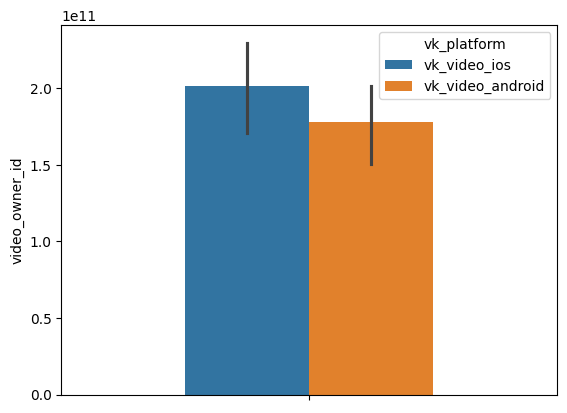

In [22]:
#Подавляющие число пользователей на платформе андроид
sns.barplot(data = filter_df, y='video_owner_id', hue='vk_platform', width=0.5) 

In [23]:
#доля пользователей на платформу
filter_df.vk_platform.value_counts(normalize=True).mul(100).reset_index().round(2).rename(columns={'proportion' : 'count'})

,vk_platform,count
0,vk_video_android,69.67
1,vk_video_ios,30.33


In [24]:
# средние значения сильно различаются 
filter_df.groupby('vk_platform', as_index=False) \
         .agg({'total_view_time' : 'mean'}) \
        .rename(columns={'total_view_time' : 'mean_view_time'})

,vk_platform,mean_view_time
0,vk_video_android,1181.774908
1,vk_video_ios,2016.576271


<Axes: xlabel='vk_platform', ylabel='total_view_time'>

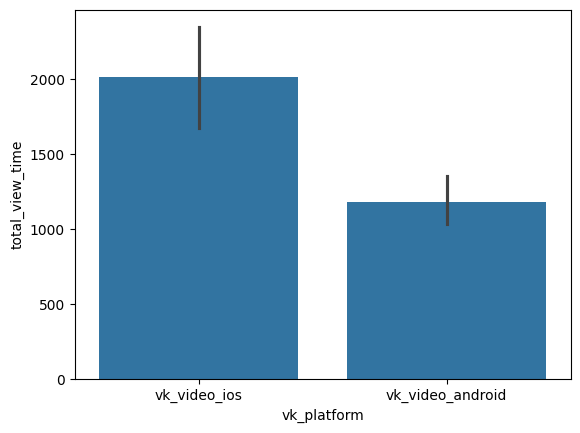

In [25]:
sns.barplot(data = filter_df, x='vk_platform', y = 'total_view_time', estimator = np.mean)

In [26]:
filter_df.groupby('vk_platform', as_index=False).agg({'total_view_time' : 'sum'}).rename(columns={'total_view_time' : 'sum_view_time'})

,vk_platform,sum_view_time
0,vk_video_android,320261
1,vk_video_ios,237956


<Axes: xlabel='vk_platform', ylabel='total_view_time'>

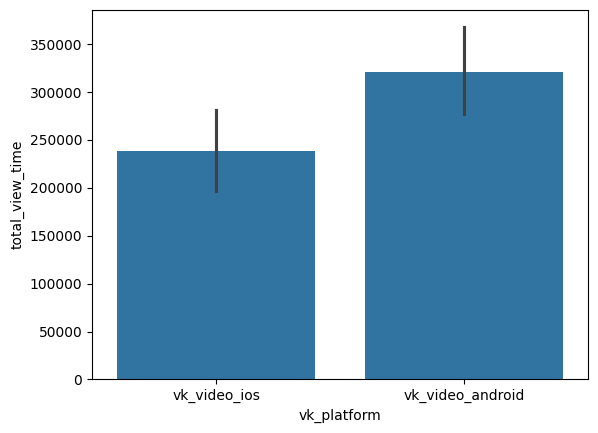

In [ ]:
# распределение времени по платформам
sns.barplot(data = filter_df, x='vk_platform', y = 'total_view_time', estimator = np.sum)

### При большой разнице средних, суммарное время просмотра разлчается не так сильно, и больше у пользователей android

### Ниже представлен график распределения просмотров по разным категориям, пользователи iphone отсутсвуют в 4 категориях, а пользователи android вообще не пользуются плейлистами сообществ

<Axes: xlabel='nav_screen', ylabel='total_view_time'>

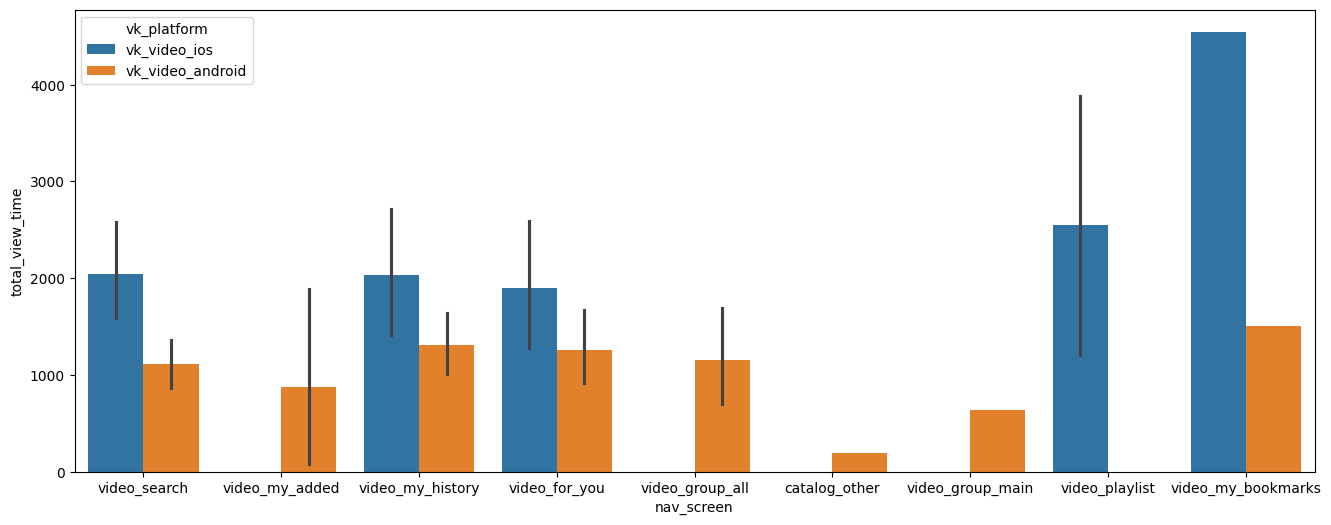

In [28]:
plt.figure(figsize=(16,6))
sns.barplot(data = filter_df, x='nav_screen', y = 'total_view_time', hue='vk_platform')